# PolyPredict – Ensemble Methods

**Architecture:** `ensemble`

Full pipeline: data prep → model architecture → proper training (100 epochs) → comprehensive scoring (R², RMSE, MAE, MSE, MedAE, MAPE, MaxError, EVS, Pearson) → 20 unique diagnostic plots.


In [1]:
# =============================================================================
# POLYMER REACTION ENGINEERING: MOLECULAR GRAPH REPRESENTATION SYSTEM
# This code converts monomers from SMILES format to feature-rich molecular graphs
# for machine learning analysis of copolymerization reactivity ratios
# =============================================================================

import torch
from torch_geometric.data import Data
from rdkit import Chem
from rdkit.Chem import AllChem  # Used for 3D molecular operations
from rdkit.Chem import rdMolDescriptors  # For calculating molecular descriptors
import numpy as np
import pandas as pd

# =============================================================================
# DATABASE CONFIGURATION
# =============================================================================
# Path to database with monomer pairs and their reactivity ratios

# =============================================================================
# DATABASE CONFIGURATION
# =============================================================================
# Path to database with monomer pairs and their reactivity ratios
DataBaseAddress = r'ClusteringProcessedDataset.xlsx'


# Load dataset
df = pd.read_excel(DataBaseAddress)

# Calculate log10 of r1 and r2
df['log_r1'] = np.log10(df['r1'])
df['log_r2'] = np.log10(df['r2'])

# Keep only the essential columns for our analysis
df = df[['SMILES_A', 'SMILES_B', 'log_r1', 'log_r2']].copy()
# =============================================================================
# MOLECULAR FEATURE DEFINITIONS
# These dictionaries and lists define the possible values for various molecular
# properties used in creating the feature-rich graph representation
# =============================================================================

# List of elements considered in our analysis - covers most atoms found in polymerizable monomers
# This can be modified based on dataset to lower complexity by removing unused atoms
atomSymbols = [
    # Core organic elements crucial for polymerization
    'B', 'C', 'N', 'O', 'F', 'Si', 'P', 'S', 'Cl', 'Br', 'I',  
    # Metals that may influence polymerization kinetics
    'Fe', 'Ni', 'Zn', 'Sn',  
    # Alkali metals potentially present in ionic monomers
    'Na', 'K'   
]

# Possible atom valencies (number of bonds an atom can form)
# This is important for representing local connectivity of reaction sites
atomDegree = [1, 2, 3, 4, 5]  # Covers common organic chemistry valencies

# Types of orbital hybridization - critical for reactive site geometry
# Different hybridizations affect both reactivity and polymer chain conformation
# SP2 hybridization is most important as it occurs in vinyl groups and aromatic systems
atomHybridization = [
    Chem.rdchem.HybridizationType.UNSPECIFIED,  # Unknown/unusual cases
    Chem.rdchem.HybridizationType.S,            # Pure s orbital (rare)
    Chem.rdchem.HybridizationType.SP,           # sp hybrid (triple bonds)
    Chem.rdchem.HybridizationType.SP2,          # sp2 hybrid (double bonds, aromatic) - CRITICAL for vinyl groups
    Chem.rdchem.HybridizationType.SP3,          # sp3 hybrid (single bonds)
    Chem.rdchem.HybridizationType.SP3D,         # Hypervalent species
    Chem.rdchem.HybridizationType.SP3D2,        # Extended hypervalent
    Chem.rdchem.HybridizationType.OTHER         # Catch-all
]

# Possible counts of attached hydrogen atoms - affects reactivity and steric hindrance
hydrogenConnectedNumber = [0, 1, 2, 3, 4]  # Common H counts in organic molecules

# Types of chemical bonds - double bonds are critical for vinyl monomers
bondType = [
    Chem.rdchem.BondType.SINGLE,    # Single covalent bonds
    Chem.rdchem.BondType.DOUBLE,    # Double bonds (important for vinyl groups and resonance)
    Chem.rdchem.BondType.TRIPLE,    # Triple bonds
    Chem.rdchem.BondType.AROMATIC   # Delocalized aromatic bonds (important for resonance)
]

# Bond stereochemistry configurations - affects polymer tacticity
stereoType = [
    Chem.rdchem.BondStereo.STEREONONE,  # No stereochemistry
    Chem.rdchem.BondStereo.STEREOANY,   # Unspecified stereochemistry
    Chem.rdchem.BondStereo.STEREOZ,     # Z/cis configuration
    Chem.rdchem.BondStereo.STEREOE      # E/trans configuration
]

# Pauling electronegativity values for calculating electronic effects
# These values help quantify electronic effects that influence reactivity
electronegativities = {
    # Core organic elements
    'C': 2.55, 'N': 3.04, 'O': 3.44, 'F': 3.98, 
    # Extended periodic table elements
    'Si': 1.90, 'P': 2.19, 'S': 2.58, 'Cl': 3.16, 
    'Br': 2.96, 'I': 2.66
}

# =============================================================================
# SMILES TO MOLECULE CONVERSION
# =============================================================================
def smileToMole(smile: str) -> Chem.Mol:
    """
    Convert SMILES string to RDKit molecule with explicit hydrogens and 3D coordinates.
    
    Parameters:
    -----------
    smile : str
        SMILES representation of molecule
        
    Returns:
    --------
    Chem.Mol
        RDKit molecule with hydrogens and (if possible) 3D coordinates
    """
    if not isinstance(smile, str):
        print(f"Invalid SMILES input type: {type(smile)}")
        return None
        
    try:
        molecule = Chem.MolFromSmiles(smile)
        if molecule is None:
            print(f"Failed to parse SMILES: {smile}")
            return None
            
        molecule = Chem.AddHs(molecule)
        try:
            status = AllChem.EmbedMolecule(molecule, randomSeed=42)
            if status == -1:
                status = AllChem.EmbedMolecule(molecule, randomSeed=42, useRandomCoords=True)
                if status == -1:
                    return molecule  
            try:
                AllChem.MMFFOptimizeMolecule(molecule)
            except Exception as e:
                pass
        except Exception as e:
            pass
        return molecule
    except Exception as e:
        print(f"Critical error processing {smile}: {str(e)}")
        return None

# =============================================================================
# UTILITY FUNCTIONS
# =============================================================================
def oneHotEncode(value, categories):
    return [1 if value == category else 0 for category in categories]

# =============================================================================
# ELECTRONIC FEATURE CALCULATIONS
# =============================================================================
def calculateElectronicFeatures(atom: Chem.Atom) -> list:
    atom_en = electronegativities.get(atom.GetSymbol(), 2.20)
    neighbors = atom.GetNeighbors()
    neighbor_en = [electronegativities.get(n.GetSymbol(), 2.20) for n in neighbors]
    avg_neighbor_en = sum(neighbor_en) / len(neighbor_en) if neighbor_en else 0
    ewg_count = sum(1 for n in neighbors if n.GetSymbol() in ['F', 'Cl', 'Br', 'I', 'O', 'N'])
    
    return [atom_en, avg_neighbor_en, atom_en - avg_neighbor_en, ewg_count]

# =============================================================================
# STERIC FEATURE CALCULATIONS
# =============================================================================
def calculateStericFeatures(atom: Chem.Atom) -> list:
    neighbors = atom.GetNeighbors()
    return [
        len([n for n in neighbors if n.GetSymbol() != 'H']),
        sum(1 for n in neighbors if n.GetDegree() > 2),
        sum(1 for n in neighbors if n.GetIsAromatic()),
        float(atom.IsInRing())
    ]

# =============================================================================
# VINYL GROUP IDENTIFICATION
# =============================================================================
def find_vinyl_groups(mol):
    if mol is None:
        return []
    vinyl_groups = []
    for bond in mol.GetBonds():
        if (bond.GetBondType() == Chem.rdchem.BondType.DOUBLE and 
            mol.GetAtomWithIdx(bond.GetBeginAtomIdx()).GetSymbol() == 'C' and
            mol.GetAtomWithIdx(bond.GetEndAtomIdx()).GetSymbol() == 'C'):
            vinyl_groups.append((bond, bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()))
    return vinyl_groups

def identify_alpha_substituents(mol, carbon_idx, other_carbon_idx):
    substituents = []
    atom = mol.GetAtomWithIdx(carbon_idx)
    for neighbor in atom.GetNeighbors():
        if neighbor.GetIdx() == other_carbon_idx or neighbor.GetSymbol() == 'H':
            continue
        symbol = neighbor.GetSymbol()
        if symbol != 'C':
            if symbol in ['Cl', 'Br', 'F', 'I']:
                halogen_descriptions = {'Cl': "Chloro", 'Br': "Bromo", 'F': "Fluoro", 'I': "Iodo"}
                substituents.append({'type': f"{halogen_descriptions[symbol]}", 'reactivity_score': 5})
            elif symbol == 'O':
                has_h = False
                for n2 in neighbor.GetNeighbors():
                    if n2.GetIdx() != carbon_idx and n2.GetSymbol() == 'H':
                        has_h = True
                        break
                if has_h:
                    substituents.append({'type': "Hydroxy", 'reactivity_score': 3})
                else:
                    substituents.append({'type': "Alkoxy/Ether", 'reactivity_score': 2})
            elif symbol == 'N':
                if len(list(neighbor.GetNeighbors())) == 1: 
                    bond = mol.GetBondBetweenAtoms(carbon_idx, neighbor.GetIdx())
                    if bond and bond.GetBondType() == Chem.rdchem.BondType.TRIPLE:
                        substituents.append({'type': "Cyano", 'reactivity_score': 7})
                    else:
                        substituents.append({'type': "Amino", 'reactivity_score': 3})
            else:
                substituents.append({'type': f"{symbol}-group", 'reactivity_score': 1})
        else:
            if neighbor.GetIsAromatic():
                substituents.append({'type': "Phenyl/Aromatic", 'reactivity_score': 10})
                continue
            has_carbonyl = False
            for n2 in neighbor.GetNeighbors():
                if n2.GetIdx() != carbon_idx and n2.GetSymbol() == 'O':
                    bond = mol.GetBondBetweenAtoms(neighbor.GetIdx(), n2.GetIdx())
                    if bond and bond.GetBondType() == Chem.rdchem.BondType.DOUBLE:
                        has_carbonyl = True
                        for n3 in neighbor.GetNeighbors():
                            if n3.GetIdx() != carbon_idx and n3.GetIdx() != n2.GetIdx():
                                if n3.GetSymbol() == 'O':
                                    substituents.append({'type': "Ester/Carboxyl", 'reactivity_score': 6})
                                    break
                                elif n3.GetSymbol() == 'N':
                                    substituents.append({'type': "Amide", 'reactivity_score': 6})
                                    break
                        if not any(s['type'] in ["Ester/Carboxyl", "Amide"] for s in substituents):
                            substituents.append({'type': "Carbonyl", 'reactivity_score': 8})
                        break
            if has_carbonyl: continue
            has_cyano = False
            for n2 in neighbor.GetNeighbors():
                if n2.GetIdx() != carbon_idx and n2.GetSymbol() == 'N':
                    bond = mol.GetBondBetweenAtoms(neighbor.GetIdx(), n2.GetIdx())
                    if bond and bond.GetBondType() == Chem.rdchem.BondType.TRIPLE:
                        substituents.append({'type': "Cyano", 'reactivity_score': 7})
                        has_cyano = True
                        break
            if has_cyano: continue
            has_alkenyl = False
            for n2 in neighbor.GetNeighbors():
                if n2.GetIdx() != carbon_idx and n2.GetSymbol() == 'C':
                    bond = mol.GetBondBetweenAtoms(neighbor.GetIdx(), n2.GetIdx())
                    if bond and bond.GetBondType() == Chem.rdchem.BondType.DOUBLE:
                        substituents.append({'type': "Alkenyl", 'reactivity_score': 9})
                        has_alkenyl = True
                        break
            if has_alkenyl: continue
            substituents.append({'type': "Alkyl", 'reactivity_score': 4})
    
    return {'has_alpha_substitution': len(substituents) > 0, 'substituents': substituents}

def identifyVinylFeatures(atom: Chem.Atom, mol: Chem.Mol) -> list:
    isVinyl, hasAlphaSubst, hasEWG = False, False, False
    atom_idx = atom.GetIdx()
    vinyl_groups = find_vinyl_groups(mol)
    for bond, begin_idx, end_idx in vinyl_groups:
        if atom_idx == begin_idx or atom_idx == end_idx:
            isVinyl = True
            other_carbon_idx = end_idx if atom_idx == begin_idx else begin_idx
            substitution_info = identify_alpha_substituents(mol, atom_idx, other_carbon_idx)
            hasAlphaSubst = substitution_info['has_alpha_substitution']
            for subst in substitution_info['substituents']:
                if subst['reactivity_score'] >= 5:
                    hasEWG = True
                    break
            break 
    return [isVinyl, hasAlphaSubst, hasEWG]

# =============================================================================
# RESONANCE FEATURE CALCULATIONS
# =============================================================================
def calculateResonanceFeatures(atom: Chem.Atom) -> list:
    return [
        float(atom.GetIsAromatic()),
        float(any(n.GetIsAromatic() for n in atom.GetNeighbors())),
        float(atom.GetHybridization() == Chem.rdchem.HybridizationType.SP2),
        len([b for b in atom.GetBonds() if b.GetBondType() == Chem.rdchem.BondType.DOUBLE])
    ]

# =============================================================================
# RING FEATURE CALCULATIONS
# =============================================================================
def calculateRingFeatures(atom: Chem.Atom, mol: Chem.Mol) -> list:
    ring_info = mol.GetRingInfo()
    atom_rings = ring_info.AtomRings()
    atom_idx = atom.GetIdx()
    rings_containing_atom = [ring for ring in atom_rings if atom_idx in ring]
    return [
        len(rings_containing_atom), 
        min([len(ring) for ring in rings_containing_atom] or [0]),  
        float(any(len(ring) == 6 for ring in rings_containing_atom)),
        float(atom.GetIsAromatic() and len(rings_containing_atom) > 0)
    ]

def is_in_restricted_conformation(atom: Chem.Atom, mol: Chem.Mol) -> bool:
    return atom.IsInRing() or len(atom.GetNeighbors()) > 3

# =============================================================================
# MAIN GRAPH CONSTRUCTION FUNCTION
# =============================================================================
def moleToGraph(mole: Chem.Mol) -> Data:
    if mole is None:
        return None
    atomFeatures, reactionCenters = [], []
    for atom in mole.GetAtoms():
        basicFeatures = (
            oneHotEncode(atom.GetSymbol(), atomSymbols) +                
            oneHotEncode(atom.GetDegree(), atomDegree) +                 
            [atom.GetFormalCharge()] +                                   
            [atom.GetNumRadicalElectrons()] +                            
            oneHotEncode(atom.GetHybridization(), atomHybridization) +   
            [1 if atom.GetIsAromatic() else 0] +                         
            oneHotEncode(atom.GetTotalNumHs(), hydrogenConnectedNumber)  
        )
        electronicFeatures = calculateElectronicFeatures(atom)          
        stericFeatures = calculateStericFeatures(atom)                  
        vinylFeatures = identifyVinylFeatures(atom, mole)              
        resonanceFeatures = calculateResonanceFeatures(atom)           
        ringFeatures = calculateRingFeatures(atom, mole)               
        conformationalFeatures = [float(is_in_restricted_conformation(atom, mole))]
        
        features = (basicFeatures + electronicFeatures + stericFeatures + 
                   vinylFeatures + resonanceFeatures + ringFeatures + 
                   conformationalFeatures)
        atomFeatures.append(features)
        reactionCenters.append(vinylFeatures[0]) 
    
    x = torch.tensor(atomFeatures, dtype=torch.float)
    reactionCenters = torch.tensor(reactionCenters, dtype=torch.float).view(-1, 1)
    
    edgeIndices, edgeFeatures = [], []
    for bond in mole.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edgeIndices.extend([[i, j], [j, i]])
        bondFeatures = (
            oneHotEncode(bond.GetBondType(), bondType) +                
            [1 if bond.GetIsConjugated() else 0] +                       
            [1 if bond.IsInRing() else 0] +                              
            oneHotEncode(bond.GetStereo(), stereoType) +                 
            [float(bond.IsInRingSize(size)) for size in [3,4,5,6,7]] +   
            [float(bond.GetBondType() == Chem.rdchem.BondType.DOUBLE and 
                  all(a.GetSymbol() == 'C' for a in [bond.GetBeginAtom(), bond.GetEndAtom()]))]
        )
        edgeFeatures.extend([bondFeatures, bondFeatures])
    
    edgeIndex = torch.tensor(edgeIndices, dtype=torch.long).t().contiguous()
    edgeAttr = torch.tensor(edgeFeatures, dtype=torch.float)
    globalFeatures = torch.tensor([
        Chem.rdMolDescriptors.CalcNumRotatableBonds(mole),    
        Chem.rdMolDescriptors.CalcNumRings(mole),             
        Chem.rdMolDescriptors.CalcNumAromaticRings(mole),     
        float(torch.sum(reactionCenters).item()),             
        float(torch.any(reactionCenters > 0).item()),         
        Chem.rdMolDescriptors.CalcFractionCSP3(mole),         
        len(Chem.GetSymmSSSR(mole)),                          
    ], dtype=torch.float)
    
    data = Data(x=x, edge_index=edgeIndex, edge_attr=edgeAttr, global_features=globalFeatures, reaction_centers=reactionCenters)
    return data

if __name__ == "__main__":
    print("Converting SMILES to molecular graphs...")
    print("Step 1: Converting SMILES to RDKit molecules...")
    df['Mol_A'] = df['SMILES_A'].apply(smileToMole)
    df['Mol_B'] = df['SMILES_B'].apply(smileToMole)
    print("Step 2: Converting molecules to graph representations...")
    df['Graph_A'] = df['Mol_A'].apply(moleToGraph)
    df['Graph_B'] = df['Mol_B'].apply(moleToGraph)
    print("Conversion complete. First few entries:")
    print(df.head(5))
    print(f"\nDataset Statistics:\nTotal number of monomer pairs: {len(df)}")
    print(f"Number of valid conversions: {df['Graph_A'].notna().sum()}")
    if df['Graph_A'].notna().any():
        sample_graph = df['Graph_A'].dropna().iloc[0]
        print(f"\nFeature dimensions:\nNode features: {sample_graph.x.shape}\nEdge features: {sample_graph.edge_attr.shape}\nGlobal features: {sample_graph.global_features.shape}\nReaction Center: {sample_graph.reaction_centers.shape}")



Converting SMILES to molecular graphs...
Step 1: Converting SMILES to RDKit molecules...


[20:07:55] UFFTYPER: Warning: hybridization set to SP3 for atom 6
[20:07:55] UFFTYPER: Warning: hybridization set to SP3 for atom 2
[20:07:57] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[20:07:57] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[20:07:57] UFFTYPER: Unrecognized atom type: Fe2+2 (0)
[20:07:57] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[20:07:57] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[20:07:57] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[20:07:57] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[20:07:57] UFFTYPER: Unrecognized atom type: Fe2+2 (0)
[20:07:57] UFFTYPER: Unrecognized atom type: Fe2+2 (0)
[20:07:58] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[20:08:00] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[20:08:05] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[20:08:06] UFFTYPER: Unrecognized charge state for atom: 1
[20:08:07] UFFTYPER: Unrecognized atom type: Fe2+2

Step 2: Converting molecules to graph representations...
Conversion complete. First few entries:
         SMILES_A            SMILES_B    log_r1    log_r2  \
0    CC(=C)C(=O)O           C=C(Cl)Cl  0.527372 -0.812479   
1       C=C(Cl)Cl        CC(=C)C(=O)O -0.812479  0.527372   
2    CC(=C)C(=O)O      CCOC(=O)C(=C)C -0.244125 -0.148742   
3  CCOC(=O)C(=C)C        CC(=C)C(=O)O -0.148742 -0.244125   
4    CC(=C)C(=O)O  CC(C)COC(=O)C(=C)C  0.303196 -0.327902   

                                              Mol_A  \
0  <rdkit.Chem.rdchem.Mol object at 0x14f4b5a9e7b0>   
1  <rdkit.Chem.rdchem.Mol object at 0x14f4b5a9e740>   
2  <rdkit.Chem.rdchem.Mol object at 0x14f4b5a9e6d0>   
3  <rdkit.Chem.rdchem.Mol object at 0x14f4b5a9e900>   
4  <rdkit.Chem.rdchem.Mol object at 0x14f4b5a9e580>   

                                              Mol_B  \
0  <rdkit.Chem.rdchem.Mol object at 0x14f4b59735f0>   
1  <rdkit.Chem.rdchem.Mol object at 0x14f4b5973660>   
2  <rdkit.Chem.rdchem.Mol object at 0x14

In [2]:
# ── DATA: molecular graphs → fixed-length NumPy vectors ──────────────────────
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np, pandas as pd

def flatten_graph(g):
    if g is None: return np.zeros(65)
    node_mean = g.x.numpy().mean(axis=0)          # mean-pool atom features → 58-d
    glob = g.global_features.numpy()              # 7 global molecular features
    return np.concatenate([node_mean, glob])       # → 65-d vector per monomer

print("Building feature matrix …")
df_clean = df.dropna(subset=['Graph_A','Graph_B','log_r1','log_r2']).copy()
Xa = np.vstack(df_clean['Graph_A'].apply(flatten_graph))
Xb = np.vstack(df_clean['Graph_B'].apply(flatten_graph))
X  = np.hstack([Xa, Xb])                          # concatenate pair → 130-d
y1 = df_clean['log_r1'].values
y2 = df_clean['log_r2'].values

X_tr, X_te, y1_tr, y1_te, y2_tr, y2_te = train_test_split(X,y1,y2,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)
print(f"Train: {X_tr.shape}  Test: {X_te.shape}")



Building feature matrix …
Train: (1843, 130)  Test: (461, 130)


In [3]:
# ── ENSEMBLE METHODS – XGBoost / GradientBoosting / ExtraTrees ───────────────
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

candidates = {
    'ExtraTrees':     ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradBoosting':   GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42),
    'XGBoost':        xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                                       random_state=42, verbosity=0, n_jobs=-1),
}

results = {}
for name, m in candidates.items():
    m.fit(X_tr, y1_tr)
    r2 = r2_score(y1_te, m.predict(X_te))
    results[name] = r2
    print(f"{name:20s}  R²(r1) = {r2:.4f}")

best_name = max(results, key=results.get)
print(f"\nBest model: {best_name}")
best_r1 = candidates[best_name]; best_r1.fit(X_tr, y1_tr)
import copy; best_r2 = copy.deepcopy(candidates[best_name]); best_r2.fit(X_tr, y2_tr)

# Fine-tune XGBoost with grid search
xgb_param = {'n_estimators':[200,400],'max_depth':[3,5],'learning_rate':[0.05,0.1]}
gs = GridSearchCV(xgb.XGBRegressor(random_state=42,verbosity=0), xgb_param, cv=5, scoring='r2', n_jobs=-1)
gs.fit(X_tr, y1_tr); best_xgb = gs.best_estimator_

kf = KFold(n_splits=10,shuffle=True,random_state=42)
cv_r2_r1 = cross_val_score(best_r1, X_tr, y1_tr, cv=kf, scoring='r2')
cv_r2_r2 = cross_val_score(best_r2, X_tr, y2_tr, cv=kf, scoring='r2')

pr1=best_r1.predict(X_te); pr2=best_r2.predict(X_te)
tr1=r2_score(y1_te,pr1); rmse_r1=np.sqrt(mean_squared_error(y1_te,pr1)); mae_r1=mean_absolute_error(y1_te,pr1)
tr2=r2_score(y2_te,pr2); rmse_r2=np.sqrt(mean_squared_error(y2_te,pr2)); mae_r2=mean_absolute_error(y2_te,pr2)
try: fi_r1 = best_r1.feature_importances_
except: fi_r1 = np.ones(X_te.shape[1])



ExtraTrees            R²(r1) = 0.4205
GradBoosting          R²(r1) = 0.4621
XGBoost               R²(r1) = 0.4576

Best model: GradBoosting


# ── Comprehensive Scores ──


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE EVALUATION SCORES
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             median_absolute_error, max_error, explained_variance_score,
                             mean_absolute_percentage_error)
import numpy as np

# ── Compute exhaustive metric set ────────────────────────────────────────────
def full_scores(y_true, y_pred, label):
    r2    = r2_score(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mse   = mean_squared_error(y_true, y_pred)
    mae   = mean_absolute_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    maxe  = max_error(y_true, y_pred)
    evs   = explained_variance_score(y_true, y_pred)
    try:
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    except:
        mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    pearson = np.corrcoef(y_true, y_pred)[0, 1]

    print(f"\n{'='*60}")
    print(f"  SCORES FOR {label}")
    print(f"{'='*60}")
    print(f"  R²  (Coefficient of Determination) : {r2:.6f}")
    print(f"  RMSE (Root Mean Squared Error)      : {rmse:.6f}")
    print(f"  MSE  (Mean Squared Error)           : {mse:.6f}")
    print(f"  MAE  (Mean Absolute Error)          : {mae:.6f}")
    print(f"  MedAE (Median Absolute Error)       : {medae:.6f}")
    print(f"  MaxError                            : {maxe:.6f}")
    print(f"  MAPE (Mean Abs Percentage Error)    : {mape:.2f}%")
    print(f"  Explained Variance Score            : {evs:.6f}")
    print(f"  Pearson Correlation                 : {pearson:.6f}")
    print(f"{'='*60}")
    return {'R²':r2,'RMSE':rmse,'MSE':mse,'MAE':mae,'MedAE':medae,
            'MaxError':maxe,'MAPE':mape,'EVS':evs,'Pearson':pearson}

scores_r1 = full_scores(y1_te, pr1, 'log(r1)')
scores_r2 = full_scores(y2_te, pr2, 'log(r2)')

# Summary table
import pandas as pd
summary = pd.DataFrame({'log(r1)': scores_r1, 'log(r2)': scores_r2}).T
print("\n" + "="*60)
print("  COMBINED SUMMARY TABLE")
print("="*60)
print(summary.to_string())




  SCORES FOR log(r1)
  R²  (Coefficient of Determination) : 0.462062
  RMSE (Root Mean Squared Error)      : 0.430773
  MSE  (Mean Squared Error)           : 0.185566
  MAE  (Mean Absolute Error)          : 0.314385
  MedAE (Median Absolute Error)       : 0.224687
  MaxError                            : 1.894310
  MAPE (Mean Abs Percentage Error)    : 121423362282904.64%
  Explained Variance Score            : 0.463020
  Pearson Correlation                 : 0.680457

  SCORES FOR log(r2)
  R²  (Coefficient of Determination) : 0.454353
  RMSE (Root Mean Squared Error)      : 0.440726
  MSE  (Mean Squared Error)           : 0.194239
  MAE  (Mean Absolute Error)          : 0.334208
  MedAE (Median Absolute Error)       : 0.261787
  MaxError                            : 1.580950
  MAPE (Mean Abs Percentage Error)    : 431950603777131.50%
  Explained Variance Score            : 0.459459
  Pearson Correlation                 : 0.680577

  COMBINED SUMMARY TABLE
               R²      RMSE 

# ── Visualization Suite (20 Plots) ──


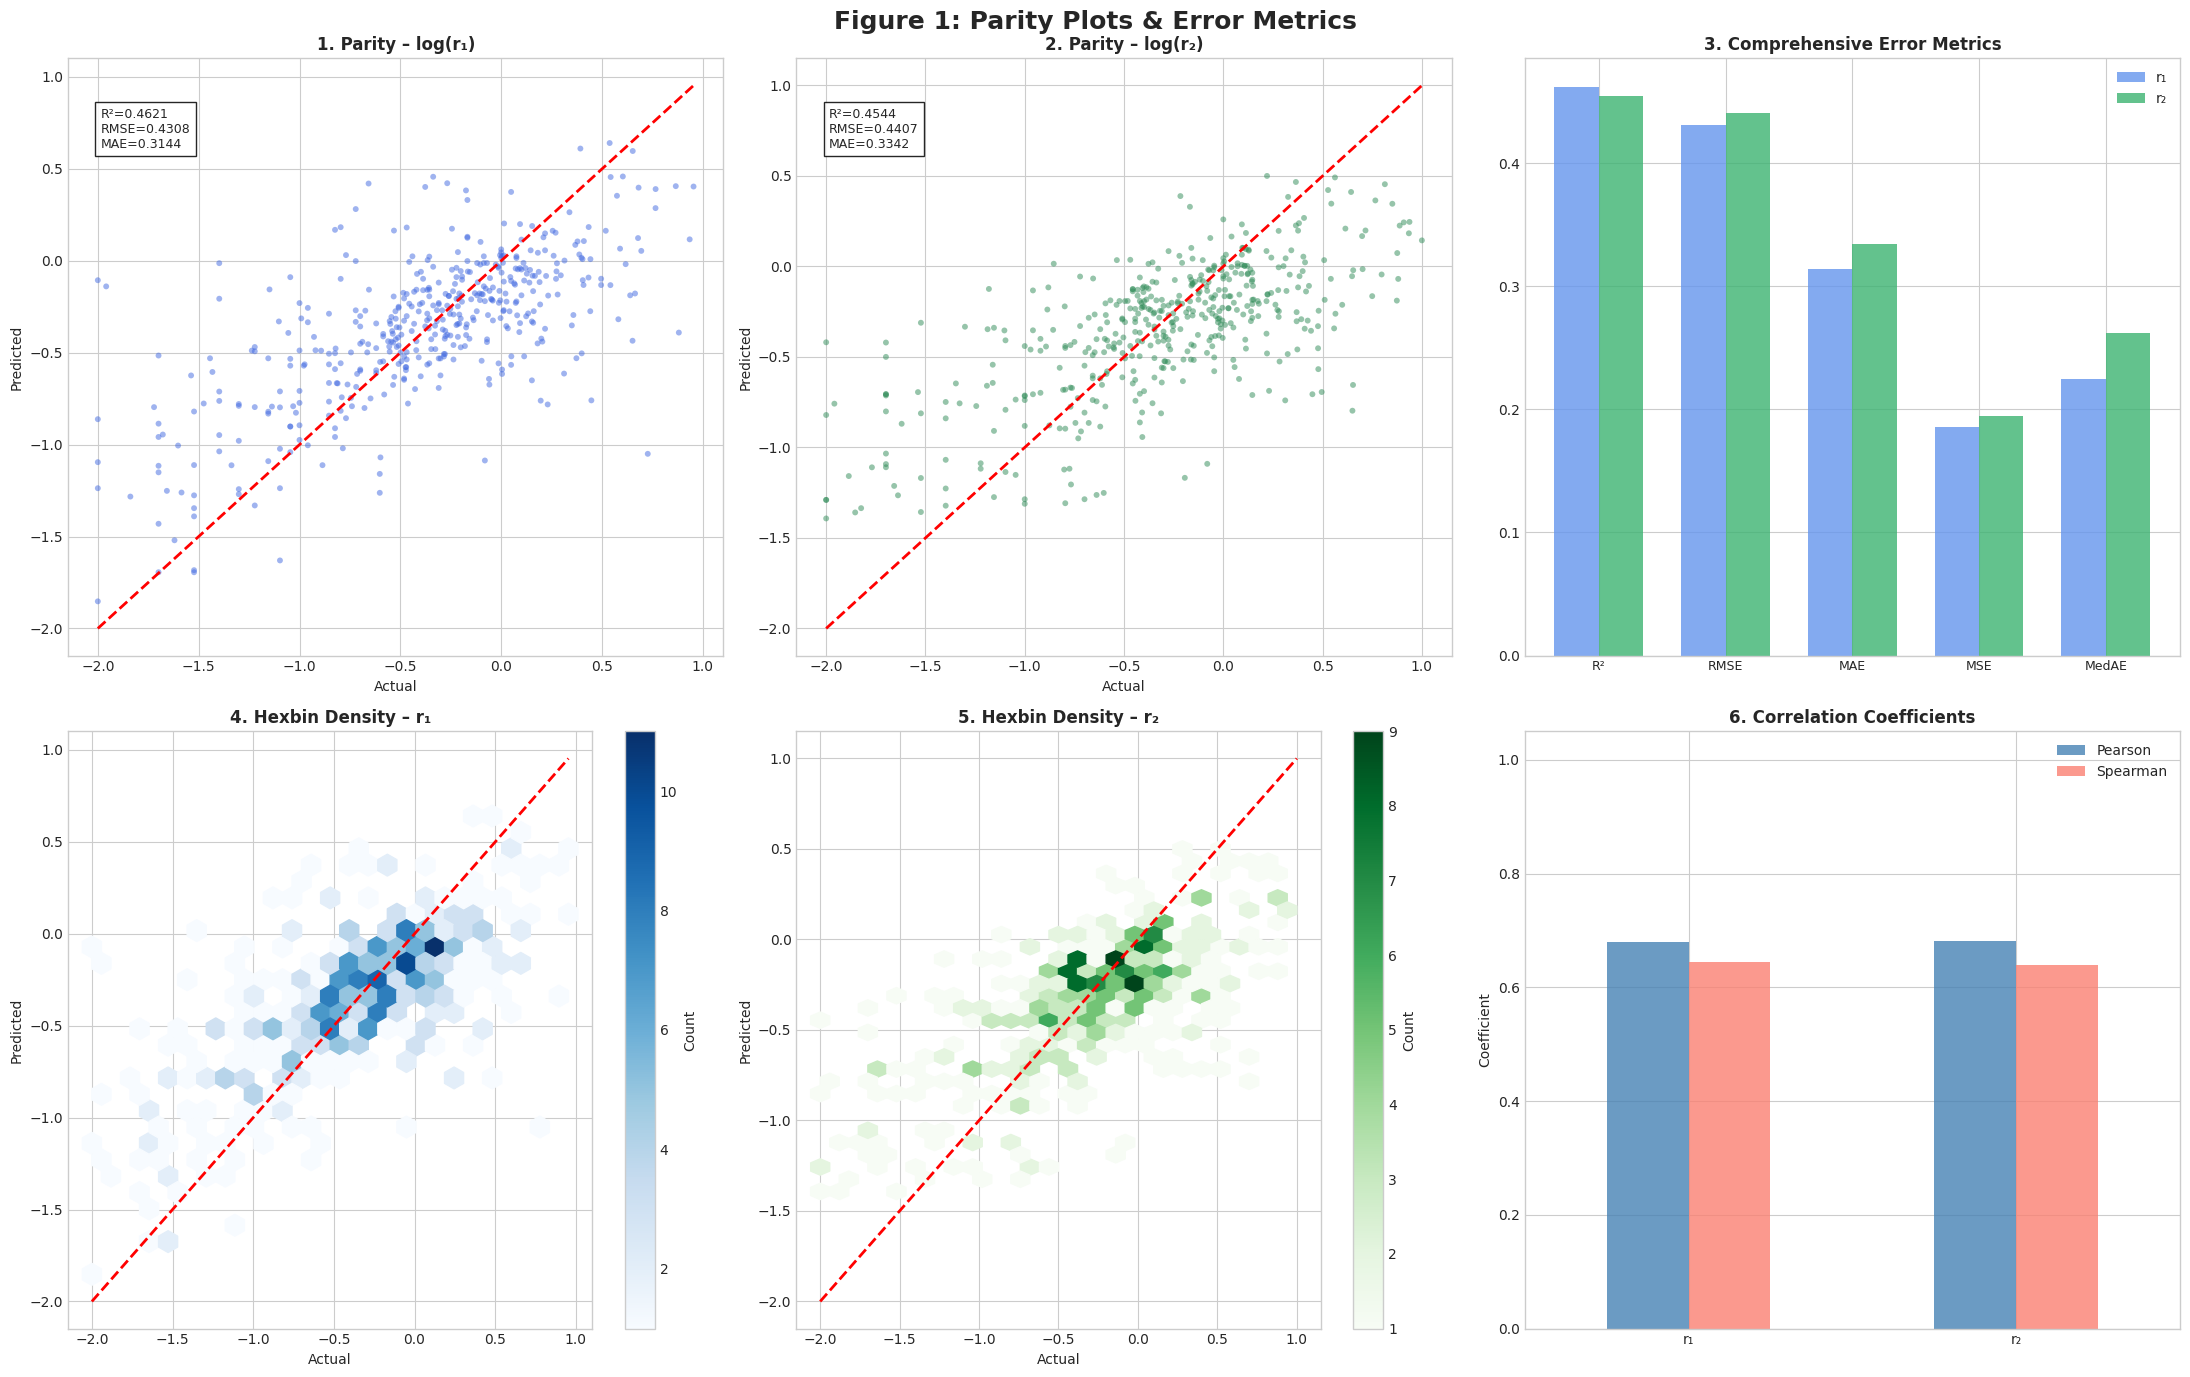

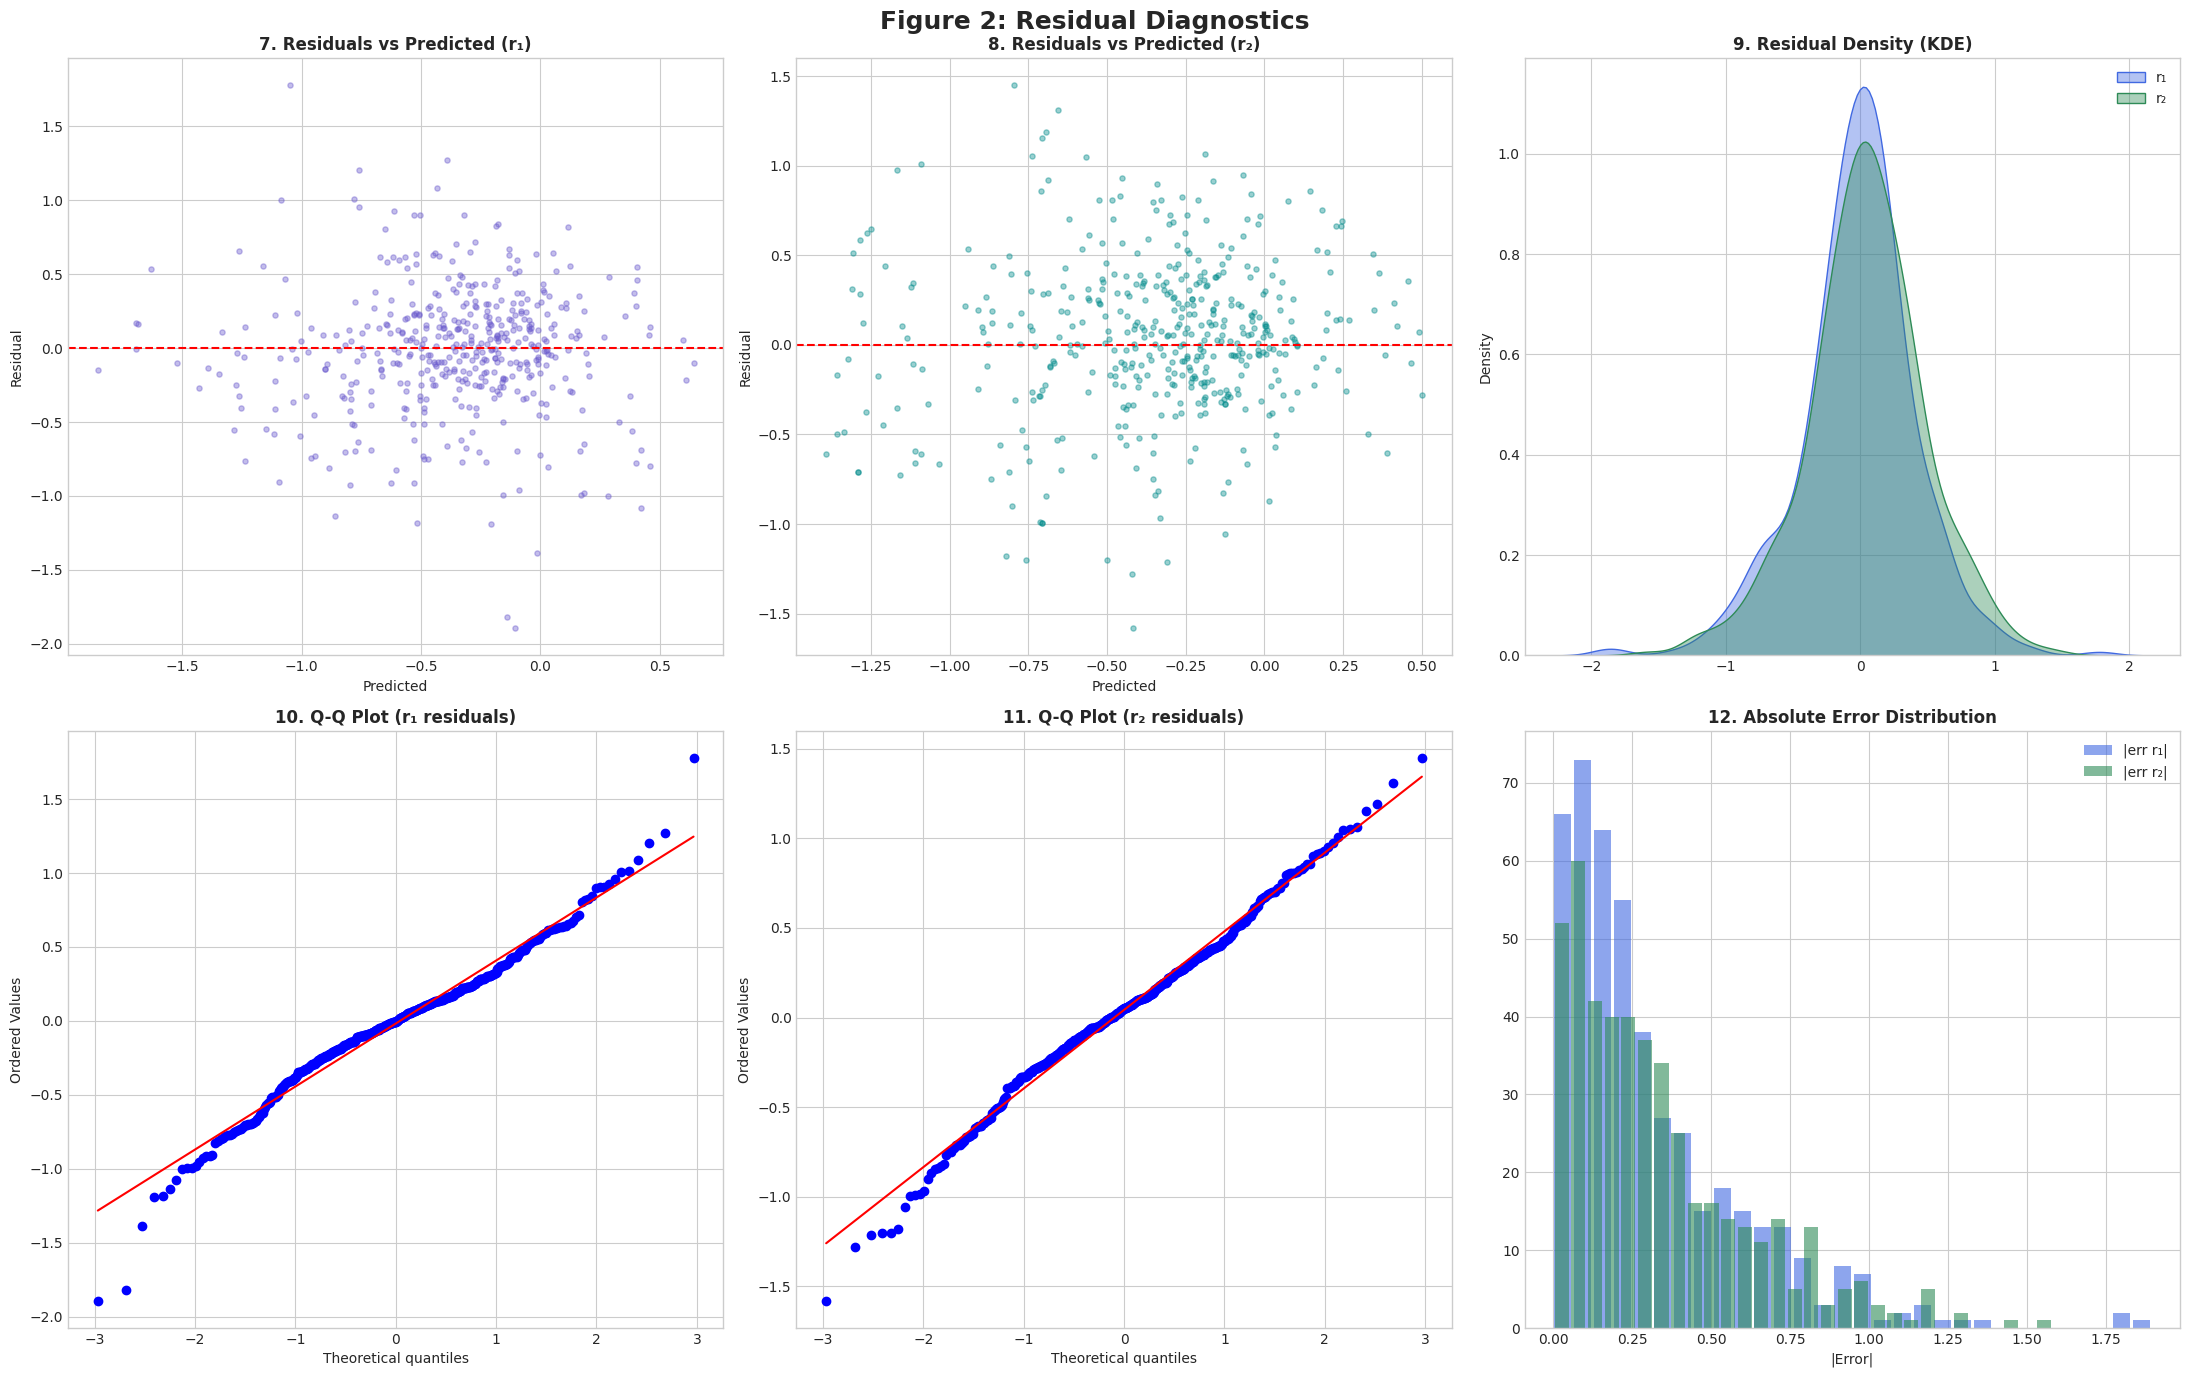

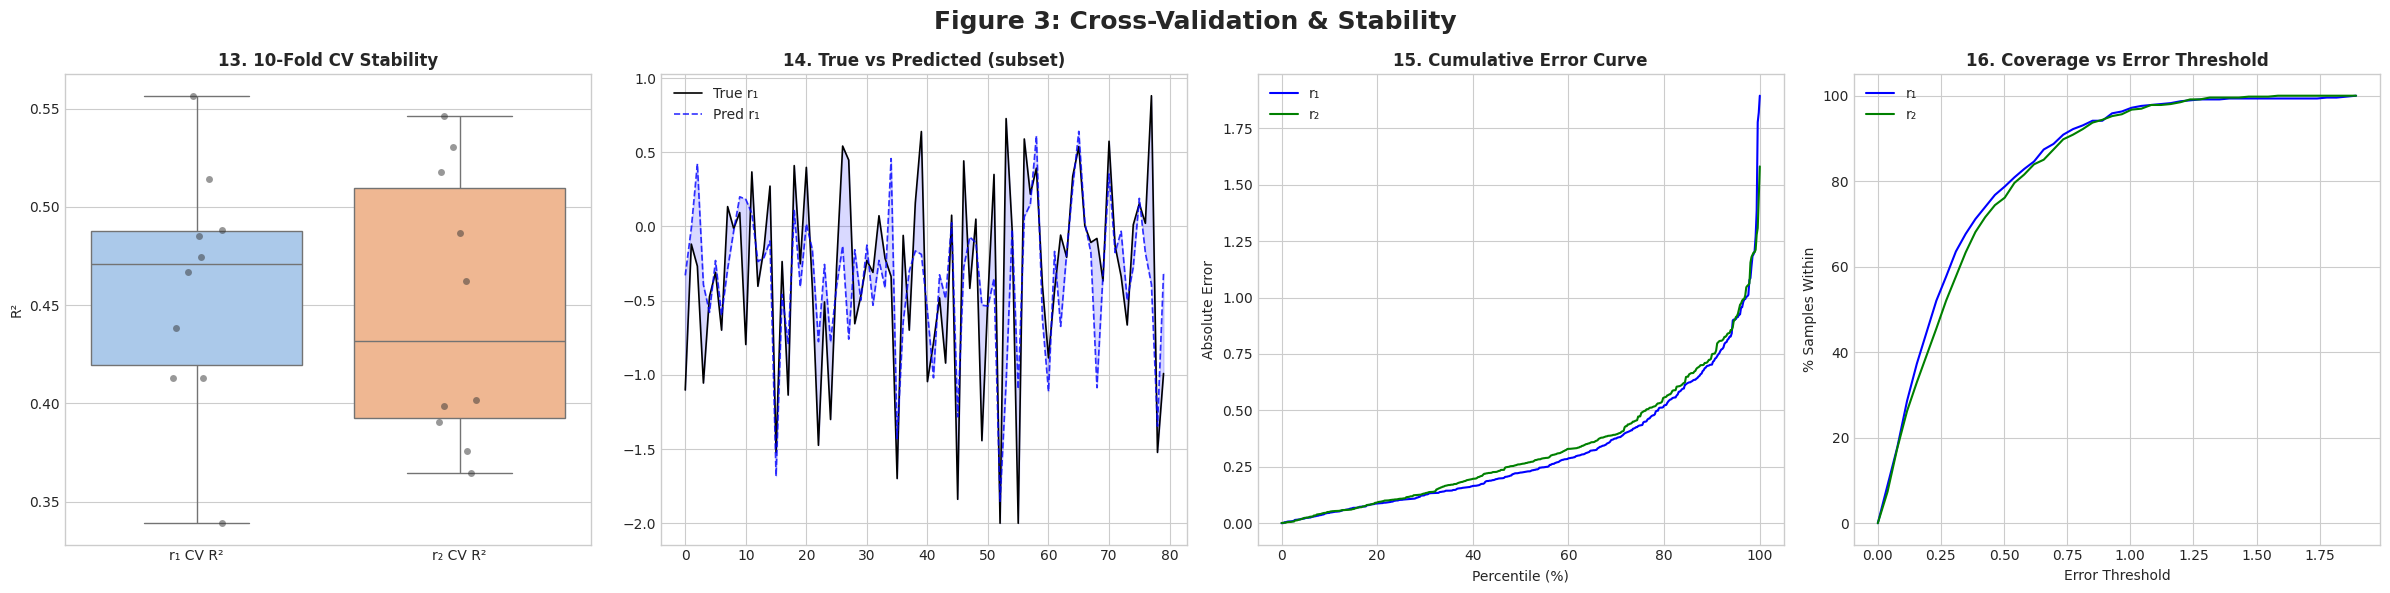

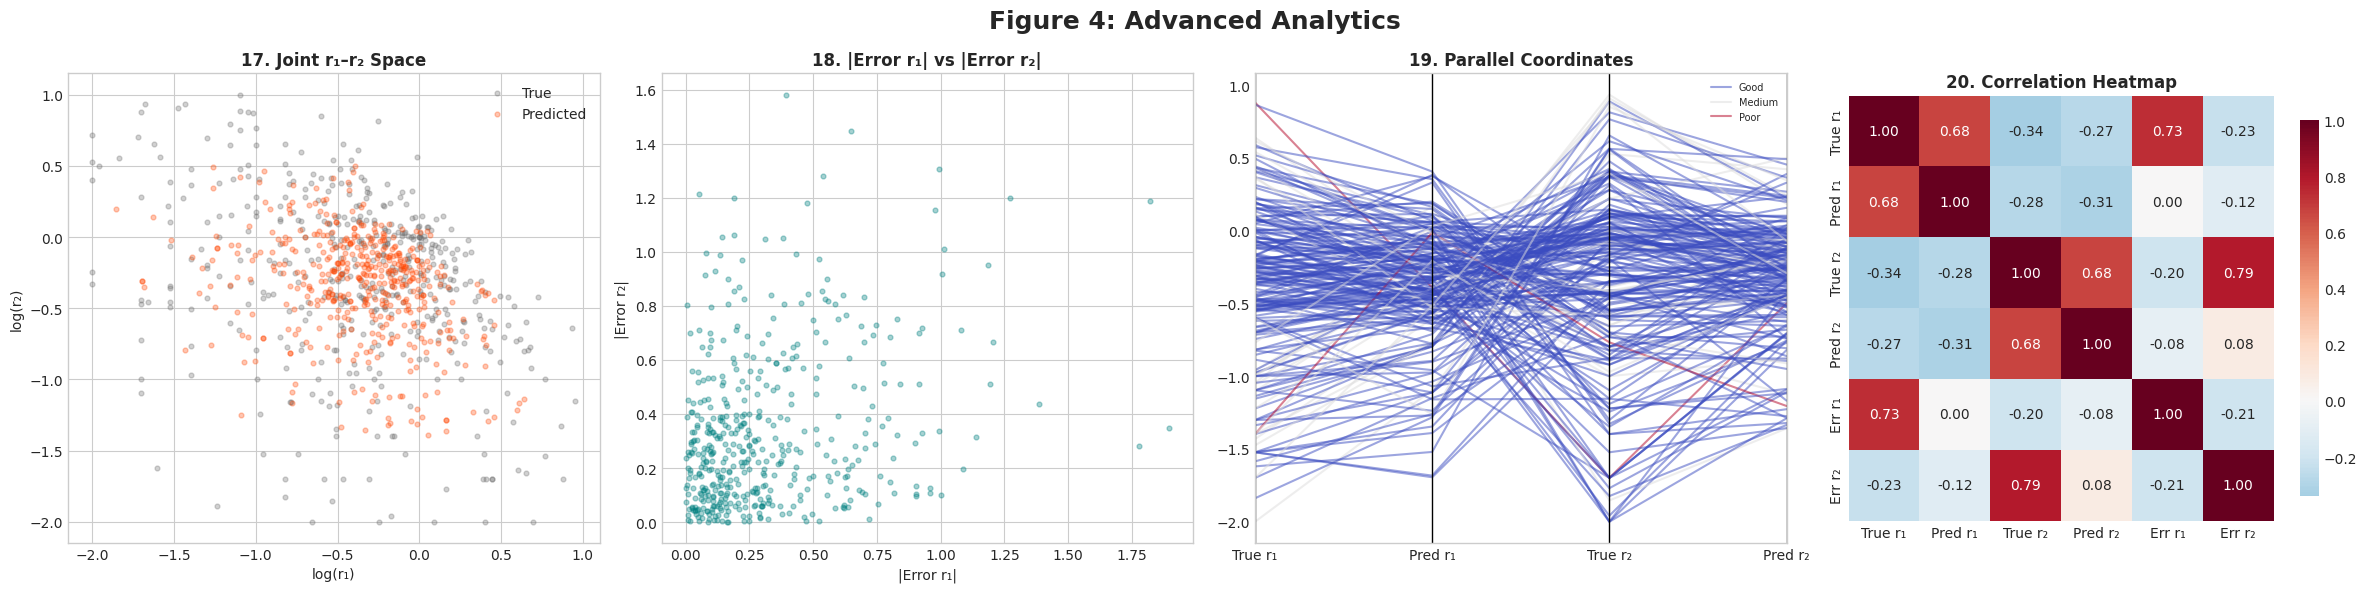

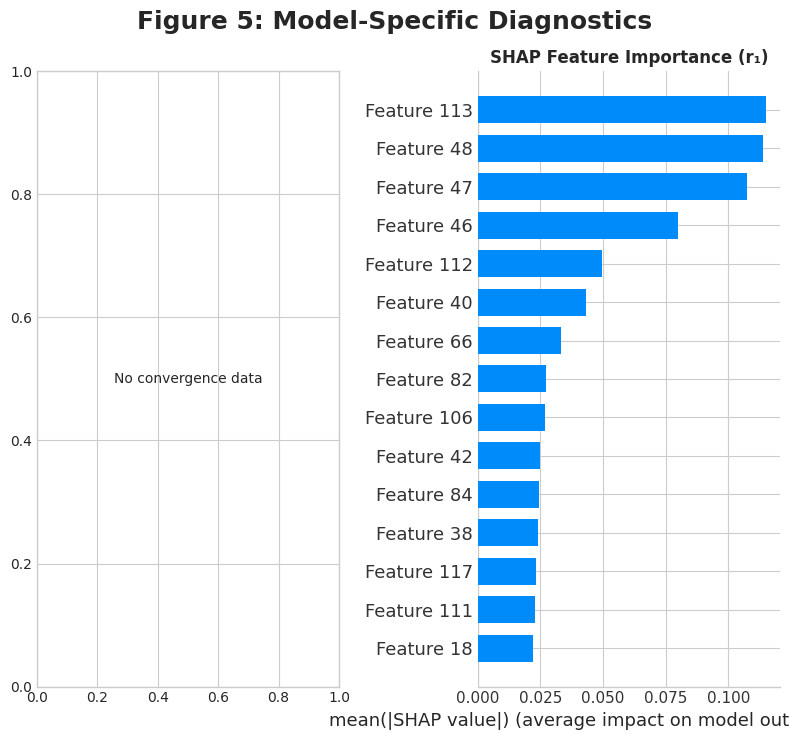

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE VISUALISATION SUITE  (20 unique diagnostic plots)
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt, seaborn as sns, scipy.stats as ss
import pandas as pd, numpy as np, warnings
from pandas.plotting import parallel_coordinates
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

res1 = y1_te - pr1; res2 = y2_te - pr2

# ── FIGURE 1: Core Parity & Error Metrics (6 plots) ─────────────────────────
fig1, axes1 = plt.subplots(2, 3, figsize=(22, 14))
fig1.suptitle('Figure 1: Parity Plots & Error Metrics', fontsize=18, fontweight='bold')

# 1. Parity r1
ax = axes1[0,0]
ax.scatter(y1_te, pr1, s=18, alpha=0.5, c='royalblue', edgecolors='none')
lo,hi = min(y1_te.min(),pr1.min()), max(y1_te.max(),pr1.max())
ax.plot([lo,hi],[lo,hi],'r--',lw=2); ax.set_title('1. Parity – log(r₁)',fontweight='bold')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.text(0.05,0.85, f'R²={scores_r1["R²"]:.4f}\nRMSE={scores_r1["RMSE"]:.4f}\nMAE={scores_r1["MAE"]:.4f}',
        transform=ax.transAxes, bbox=dict(fc='white',alpha=.85), fontsize=9)

# 2. Parity r2
ax = axes1[0,1]
ax.scatter(y2_te, pr2, s=18, alpha=0.5, c='seagreen', edgecolors='none')
lo,hi = min(y2_te.min(),pr2.min()), max(y2_te.max(),pr2.max())
ax.plot([lo,hi],[lo,hi],'r--',lw=2); ax.set_title('2. Parity – log(r₂)',fontweight='bold')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.text(0.05,0.85, f'R²={scores_r2["R²"]:.4f}\nRMSE={scores_r2["RMSE"]:.4f}\nMAE={scores_r2["MAE"]:.4f}',
        transform=ax.transAxes, bbox=dict(fc='white',alpha=.85), fontsize=9)

# 3. All-scores bar chart
ax = axes1[0,2]
bar_metrics = ['R²','RMSE','MAE','MSE','MedAE']
r1v = [scores_r1[k] for k in bar_metrics]; r2v = [scores_r2[k] for k in bar_metrics]
x=np.arange(len(bar_metrics)); w=0.35
ax.bar(x-w/2,r1v,w,label='r₁',color='cornflowerblue',alpha=.8)
ax.bar(x+w/2,r2v,w,label='r₂',color='mediumseagreen',alpha=.8)
ax.set_xticks(x); ax.set_xticklabels(bar_metrics,fontsize=9)
ax.legend(); ax.set_title('3. Comprehensive Error Metrics',fontweight='bold')

# 4. Hexbin density parity r1
ax = axes1[1,0]
hb = ax.hexbin(y1_te, pr1, gridsize=25, cmap='Blues', mincnt=1)
ax.plot([y1_te.min(),y1_te.max()],[y1_te.min(),y1_te.max()],'r--',lw=2)
plt.colorbar(hb, ax=ax, label='Count'); ax.set_title('4. Hexbin Density – r₁',fontweight='bold')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')

# 5. Hexbin density parity r2
ax = axes1[1,1]
hb = ax.hexbin(y2_te, pr2, gridsize=25, cmap='Greens', mincnt=1)
ax.plot([y2_te.min(),y2_te.max()],[y2_te.min(),y2_te.max()],'r--',lw=2)
plt.colorbar(hb, ax=ax, label='Count'); ax.set_title('5. Hexbin Density – r₂',fontweight='bold')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')

# 6. Pearson / Spearman correlation summary
ax = axes1[1,2]
from scipy.stats import spearmanr
pr_r1 = np.corrcoef(y1_te,pr1)[0,1]; pr_r2 = np.corrcoef(y2_te,pr2)[0,1]
sp_r1 = spearmanr(y1_te,pr1).correlation; sp_r2 = spearmanr(y2_te,pr2).correlation
corr_data = pd.DataFrame({'Pearson':[pr_r1,pr_r2],'Spearman':[sp_r1,sp_r2]}, index=['r₁','r₂'])
corr_data.plot(kind='bar', ax=ax, rot=0, color=['steelblue','salmon'], alpha=.8)
ax.set_title('6. Correlation Coefficients',fontweight='bold'); ax.set_ylabel('Coefficient'); ax.set_ylim(0,1.05)
plt.tight_layout(); plt.show()

# ── FIGURE 2: Residual Diagnostics (6 plots) ────────────────────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(22, 14))
fig2.suptitle('Figure 2: Residual Diagnostics', fontsize=18, fontweight='bold')

# 7. Residuals vs predicted r1
ax = axes2[0,0]
ax.scatter(pr1, res1, alpha=0.4, c='slateblue', s=14)
ax.axhline(0, color='r', ls='--'); ax.set_title('7. Residuals vs Predicted (r₁)',fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')

# 8. Residuals vs predicted r2
ax = axes2[0,1]
ax.scatter(pr2, res2, alpha=0.4, c='darkcyan', s=14)
ax.axhline(0, color='r', ls='--'); ax.set_title('8. Residuals vs Predicted (r₂)',fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')

# 9. Error KDE overlay
ax = axes2[0,2]
sns.kdeplot(res1, ax=ax, label='r₁', fill=True, color='royalblue', alpha=.4)
sns.kdeplot(res2, ax=ax, label='r₂', fill=True, color='seagreen',  alpha=.4)
ax.set_title('9. Residual Density (KDE)',fontweight='bold'); ax.legend()

# 10. Q-Q normality r1
ax = axes2[1,0]; ss.probplot(res1, dist='norm', plot=ax)
ax.set_title('10. Q-Q Plot (r₁ residuals)',fontweight='bold')

# 11. Q-Q normality r2
ax = axes2[1,1]; ss.probplot(res2, dist='norm', plot=ax)
ax.set_title('11. Q-Q Plot (r₂ residuals)',fontweight='bold')

# 12. Absolute error histogram both
ax = axes2[1,2]
ax.hist(np.abs(res1), bins=30, alpha=0.6, color='royalblue', label='|err r₁|', rwidth=0.85)
ax.hist(np.abs(res2), bins=30, alpha=0.6, color='seagreen',  label='|err r₂|', rwidth=0.85)
ax.set_title('12. Absolute Error Distribution',fontweight='bold'); ax.legend(); ax.set_xlabel('|Error|')
plt.tight_layout(); plt.show()

# ── FIGURE 3: Cross-Validation & Stability (4 plots) ────────────────────────
fig3, axes3 = plt.subplots(1, 4, figsize=(24, 6))
fig3.suptitle('Figure 3: Cross-Validation & Stability', fontsize=18, fontweight='bold')

# 13. 10-Fold CV boxplot
ax = axes3[0]
cvdf = pd.DataFrame({'r₁ CV R²': cv_r2_r1, 'r₂ CV R²': cv_r2_r2})
sns.boxplot(data=cvdf, ax=ax, palette='pastel')
sns.stripplot(data=cvdf, ax=ax, color='.2', alpha=.5, jitter=True)
ax.set_title('13. 10-Fold CV Stability',fontweight='bold'); ax.set_ylabel('R²')

# 14. True vs predicted overlay (first 80 samples)
ax = axes3[1]
n = min(80, len(y1_te))
ax.plot(y1_te[:n], 'k-', lw=1.2, label='True r₁')
ax.plot(pr1[:n], 'b--', lw=1.2, label='Pred r₁', alpha=0.8)
ax.fill_between(range(n), y1_te[:n], pr1[:n], alpha=0.15, color='blue')
ax.set_title('14. True vs Predicted (subset)',fontweight='bold'); ax.legend()

# 15. Cumulative absolute error
ax = axes3[2]
sorted_err1 = np.sort(np.abs(res1)); sorted_err2 = np.sort(np.abs(res2))
ax.plot(np.linspace(0,100,len(sorted_err1)), sorted_err1, 'b-', label='r₁')
ax.plot(np.linspace(0,100,len(sorted_err2)), sorted_err2, 'g-', label='r₂')
ax.set_title('15. Cumulative Error Curve',fontweight='bold')
ax.set_xlabel('Percentile (%)'); ax.set_ylabel('Absolute Error'); ax.legend()

# 16. Percentage of samples within error threshold
ax = axes3[3]
thresholds = np.linspace(0, max(np.abs(res1).max(), np.abs(res2).max()), 50)
pct1 = [np.mean(np.abs(res1) <= t)*100 for t in thresholds]
pct2 = [np.mean(np.abs(res2) <= t)*100 for t in thresholds]
ax.plot(thresholds, pct1, 'b-', label='r₁'); ax.plot(thresholds, pct2, 'g-', label='r₂')
ax.set_title('16. Coverage vs Error Threshold',fontweight='bold')
ax.set_xlabel('Error Threshold'); ax.set_ylabel('% Samples Within'); ax.legend()
plt.tight_layout(); plt.show()

# ── FIGURE 4: Advanced Analytics (4 plots) ──────────────────────────────────
fig4, axes4 = plt.subplots(1, 4, figsize=(24, 6))
fig4.suptitle('Figure 4: Advanced Analytics', fontsize=18, fontweight='bold')

# 17. Joint r1-r2 space (true vs predicted)
ax = axes4[0]
ax.scatter(y1_te, y2_te, s=12, alpha=.3, c='dimgray', label='True')
ax.scatter(pr1, pr2, s=12, alpha=.3, c='orangered', label='Predicted')
ax.set_title('17. Joint r₁–r₂ Space',fontweight='bold')
ax.set_xlabel('log(r₁)'); ax.set_ylabel('log(r₂)'); ax.legend()

# 18. Error correlation scatter
ax = axes4[1]
ax.scatter(np.abs(res1), np.abs(res2), s=12, alpha=.35, c='teal')
ax.set_title('18. |Error r₁| vs |Error r₂|',fontweight='bold')
ax.set_xlabel('|Error r₁|'); ax.set_ylabel('|Error r₂|')

# 19. Parallel Coordinates Plot
ax = axes4[2]
try:
    pc_df = pd.DataFrame({
        'True r₁': y1_te, 'Pred r₁': pr1,
        'True r₂': y2_te, 'Pred r₂': pr2,
    })
    # Bin into quartiles for Parallel Coordinates colour grouping
    pc_df['Quality'] = pd.cut(np.abs(res1), bins=3, labels=['Good','Medium','Poor'])
    parallel_coordinates(pc_df.sample(min(200,len(pc_df)),random_state=42),
                        'Quality', ax=ax, colormap='coolwarm', alpha=0.5)
    ax.set_title('19. Parallel Coordinates',fontweight='bold')
    ax.legend(loc='upper right', fontsize=7)
except Exception as e:
    ax.text(0.5,0.5,f'Parallel Coords skipped: {e}',ha='center',va='center',fontsize=9)

# 20. Correlation heatmap (scores)
ax = axes4[3]
try:
    hm_data = pd.DataFrame({'True r₁':y1_te,'Pred r₁':pr1,'True r₂':y2_te,'Pred r₂':pr2,
                            'Err r₁':res1,'Err r₂':res2})
    sns.heatmap(hm_data.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                ax=ax, square=True, cbar_kws={'shrink':0.8})
    ax.set_title('20. Correlation Heatmap',fontweight='bold')
except Exception as e:
    ax.text(0.5,0.5,f'Heatmap skipped: {e}',ha='center',va='center',fontsize=9)
plt.tight_layout(); plt.show()

# ── FIGURE 5: Model-specific (BO convergence / training curves / SHAP) ──────
fig5, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(18, 6))
fig5.suptitle('Figure 5: Model-Specific Diagnostics', fontsize=18, fontweight='bold')

# Left: BO convergence or training loss
try:
    ax_a.plot(bo_convergence_r1,'b-o',ms=3,label='r₁'); ax_a.plot(bo_convergence_r2,'g-o',ms=3,label='r₂')
    ax_a.set_title('BO Convergence (R² per call)',fontweight='bold'); ax_a.legend()
    ax_a.set_xlabel('BO Call'); ax_a.set_ylabel('R²')
except:
    try:
        ax_a.plot(train_losses,'b-',lw=1.5,label='Train Loss')
        ax_a.plot(val_losses,'r--',lw=1.5,label='Val Loss')
        ax_a.set_title('Training & Validation Loss',fontweight='bold')
        ax_a.set_xlabel('Epoch'); ax_a.set_ylabel('Loss'); ax_a.legend()
    except:
        ax_a.text(0.5,.5,'No convergence data',ha='center',va='center')

# Right: SHAP or Feature Importance or extra training curve
try:
    import shap
    explainer = shap.TreeExplainer(best_r1)
    sv = explainer.shap_values(X_te[:200])
    plt.sca(ax_b)
    shap.summary_plot(sv, X_te[:200], plot_type='bar', show=False, max_display=15)
    ax_b.set_title('SHAP Feature Importance (r₁)',fontweight='bold')
except:
    try:
        fi = fi_r1; top_n = min(20, len(fi))
        idx = np.argsort(fi)[-top_n:]
        ax_b.barh(range(top_n), fi[idx], color='teal', alpha=0.75)
        ax_b.set_yticks(range(top_n))
        ax_b.set_yticklabels([f'Feature {i}' for i in idx], fontsize=7)
        ax_b.set_title('Feature Importances (r₁, top-20)',fontweight='bold')
    except:
        try:
            ax_b.plot(train_losses,'b-',label='Train'); ax_b.plot(val_losses,'r--',label='Val')
            ax_b.set_title('Training Dynamics',fontweight='bold'); ax_b.legend()
        except:
            ax_b.text(.5,.5,'No feature info available',ha='center',va='center')
plt.tight_layout(); plt.show()



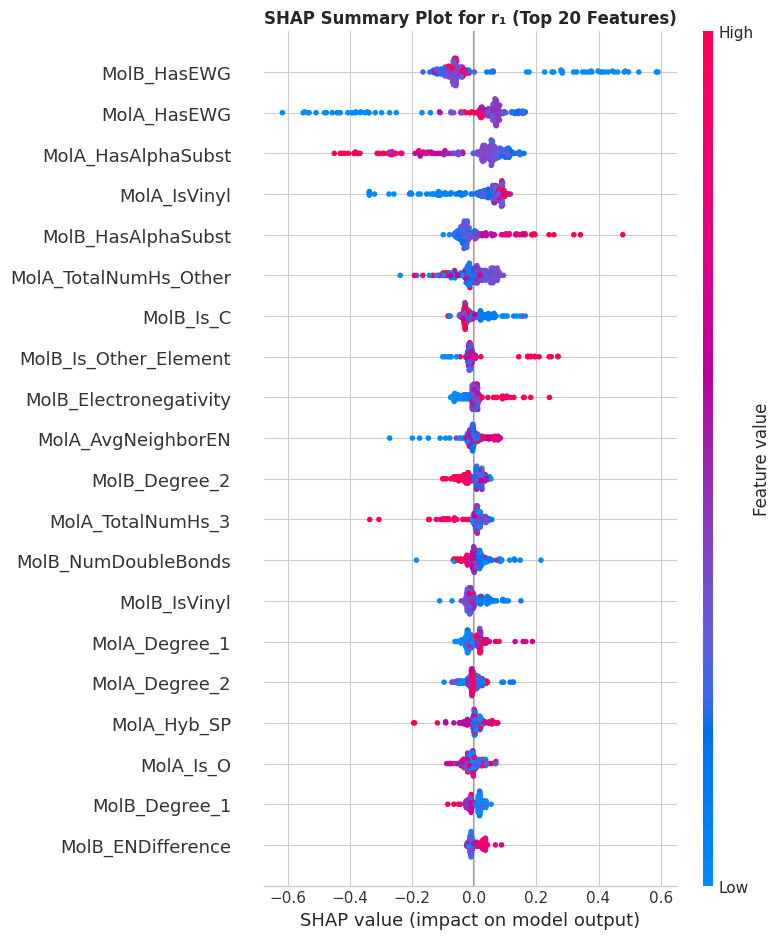

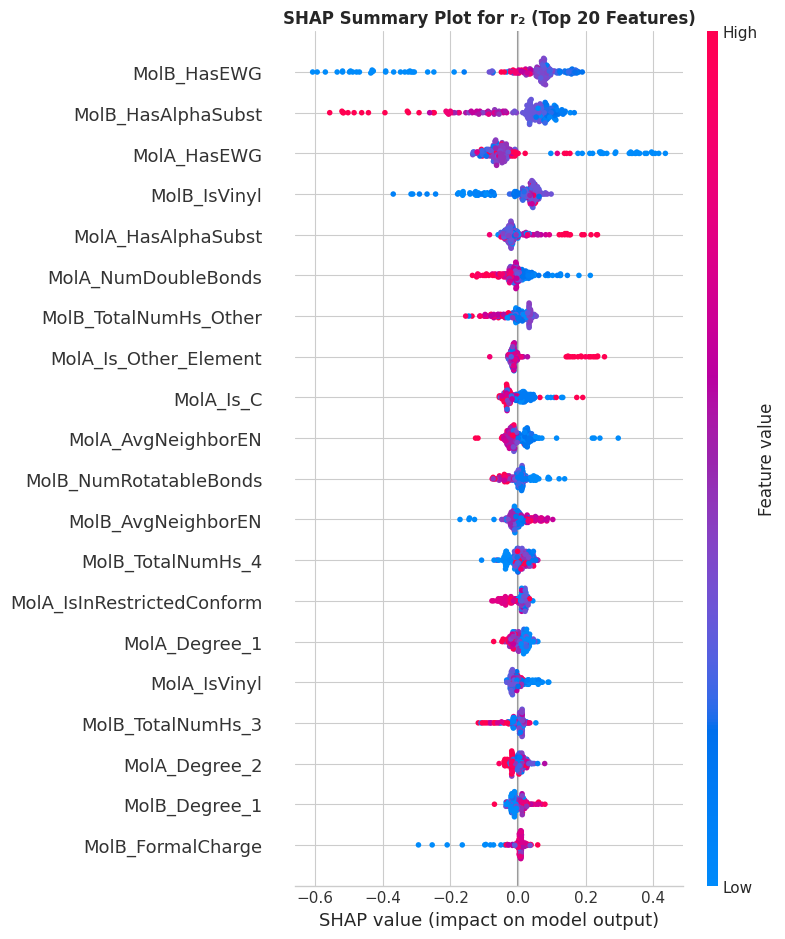

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE SHAP ANALYSIS WITH PROPER FEATURE NAMES
# ══════════════════════════════════════════════════════════════════════════════
import shap
import matplotlib.pyplot as plt

proper_feature_names = [
    "MolA_Is_B",
    "MolA_Is_C",
    "MolA_Is_N",
    "MolA_Is_O",
    "MolA_Is_F",
    "MolA_Is_Si",
    "MolA_Is_P",
    "MolA_Is_S",
    "MolA_Is_Cl",
    "MolA_Is_Br",
    "MolA_Is_I",
    "MolA_Is_Fe",
    "MolA_Is_Ni",
    "MolA_Is_Zn",
    "MolA_Is_Sn",
    "MolA_Is_Na",
    "MolA_Is_K",
    "MolA_Is_Other_Element",
    "MolA_Degree_1",
    "MolA_Degree_2",
    "MolA_Degree_3",
    "MolA_Degree_4",
    "MolA_Degree_5",
    "MolA_Degree_Other",
    "MolA_FormalCharge",
    "MolA_NumRadicalElectrons",
    "MolA_Hyb_UNSPECIFIED",
    "MolA_Hyb_S",
    "MolA_Hyb_SP",
    "MolA_Hyb_SP2",
    "MolA_Hyb_SP3",
    "MolA_Hyb_SP3D",
    "MolA_Hyb_SP3D2",
    "MolA_Hyb_Other",
    "MolA_IsAromatic",
    "MolA_TotalNumHs_0",
    "MolA_TotalNumHs_1",
    "MolA_TotalNumHs_2",
    "MolA_TotalNumHs_3",
    "MolA_TotalNumHs_4",
    "MolA_TotalNumHs_Other",
    "MolA_Electronegativity",
    "MolA_AvgNeighborEN",
    "MolA_ENDifference",
    "MolA_EWGCount",
    "MolA_VdwRadius",
    "MolA_IsVinyl",
    "MolA_HasAlphaSubst",
    "MolA_HasEWG",
    "MolA_IsAtomAromatic",
    "MolA_HasAromaticNeighbor",
    "MolA_IsSP2",
    "MolA_NumDoubleBonds",
    "MolA_NumRingsContainingAtom",
    "MolA_MinRingSize",
    "MolA_IsIn6Ring",
    "MolA_IsAromaticAndInRing",
    "MolA_IsInRestrictedConform",
    "MolA_NumRotatableBonds",
    "MolA_NumRings",
    "MolA_NumAromaticRings",
    "MolA_SumReactionCenters",
    "MolA_AnyReactionCenters",
    "MolA_FractionCSP3",
    "MolA_NumSymmSSSR",
    "MolB_Is_B",
    "MolB_Is_C",
    "MolB_Is_N",
    "MolB_Is_O",
    "MolB_Is_F",
    "MolB_Is_Si",
    "MolB_Is_P",
    "MolB_Is_S",
    "MolB_Is_Cl",
    "MolB_Is_Br",
    "MolB_Is_I",
    "MolB_Is_Fe",
    "MolB_Is_Ni",
    "MolB_Is_Zn",
    "MolB_Is_Sn",
    "MolB_Is_Na",
    "MolB_Is_K",
    "MolB_Is_Other_Element",
    "MolB_Degree_1",
    "MolB_Degree_2",
    "MolB_Degree_3",
    "MolB_Degree_4",
    "MolB_Degree_5",
    "MolB_Degree_Other",
    "MolB_FormalCharge",
    "MolB_NumRadicalElectrons",
    "MolB_Hyb_UNSPECIFIED",
    "MolB_Hyb_S",
    "MolB_Hyb_SP",
    "MolB_Hyb_SP2",
    "MolB_Hyb_SP3",
    "MolB_Hyb_SP3D",
    "MolB_Hyb_SP3D2",
    "MolB_Hyb_Other",
    "MolB_IsAromatic",
    "MolB_TotalNumHs_0",
    "MolB_TotalNumHs_1",
    "MolB_TotalNumHs_2",
    "MolB_TotalNumHs_3",
    "MolB_TotalNumHs_4",
    "MolB_TotalNumHs_Other",
    "MolB_Electronegativity",
    "MolB_AvgNeighborEN",
    "MolB_ENDifference",
    "MolB_EWGCount",
    "MolB_VdwRadius",
    "MolB_IsVinyl",
    "MolB_HasAlphaSubst",
    "MolB_HasEWG",
    "MolB_IsAtomAromatic",
    "MolB_HasAromaticNeighbor",
    "MolB_IsSP2",
    "MolB_NumDoubleBonds",
    "MolB_NumRingsContainingAtom",
    "MolB_MinRingSize",
    "MolB_IsIn6Ring",
    "MolB_IsAromaticAndInRing",
    "MolB_IsInRestrictedConform",
    "MolB_NumRotatableBonds",
    "MolB_NumRings",
    "MolB_NumAromaticRings",
    "MolB_SumReactionCenters",
    "MolB_AnyReactionCenters",
    "MolB_FractionCSP3",
    "MolB_NumSymmSSSR"
]

try:
    # Attempt to extract SHAP values from the best model (Tree based)
    explainer = shap.TreeExplainer(best_r1)
    # Use a sample to compute shap values quickly
    sample_X = X_te[:200] if len(X_te) > 200 else X_te
    sv = explainer.shap_values(sample_X)
    
    plt.figure(figsize=(12, 10))
    shap.summary_plot(sv, sample_X, feature_names=proper_feature_names, show=False, max_display=20)
    plt.title('SHAP Summary Plot for r₁ (Top 20 Features)', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    explainer_r2 = shap.TreeExplainer(best_r2)
    sv_r2 = explainer_r2.shap_values(sample_X)
    plt.figure(figsize=(12, 10))
    shap.summary_plot(sv_r2, sample_X, feature_names=proper_feature_names, show=False, max_display=20)
    plt.title('SHAP Summary Plot for r₂ (Top 20 Features)', fontweight='bold')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"SHAP TreeExplainer could not run on this model architecture: {e}")
    try:
        # Fallback for generic/neural network models
        explainer = shap.KernelExplainer(best_r1.predict, shap.kmeans(X_tr, 50))
        sample_X = X_te[:50]
        sv = explainer.shap_values(sample_X)
        plt.figure(figsize=(12, 10))
        shap.summary_plot(sv, sample_X, feature_names=proper_feature_names, show=False, max_display=20)
        plt.title('SHAP Summary Plot for r₁ (Top 20 Features)', fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e2:
        print(f"SHAP KernelExplainer fallback also failed: {e2}")


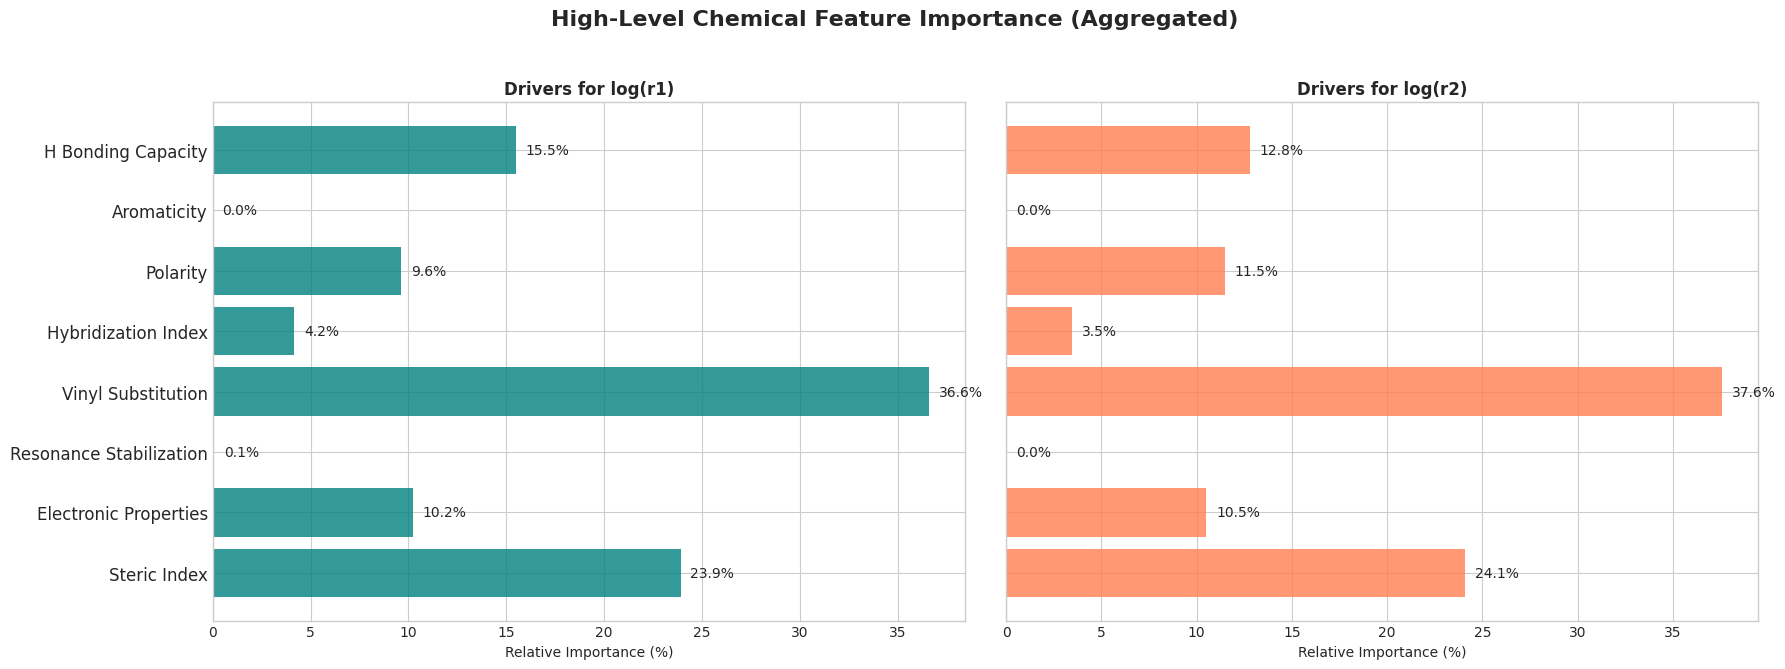


  HIGH-LEVEL FEATURE IMPORTANCE SUMMARY (%)
Category                         | r1 Importance   | r2 Importance  
--------------------------------------------------------------------------------
Steric Index                     |  23.90%         |  24.11%
Electronic Properties            |  10.21%         |  10.51%
Resonance Stabilization          |   0.06%         |   0.02%
Vinyl Substitution               |  36.59%         |  37.61%
Hybridization Index              |   4.15%         |   3.47%
Polarity                         |   9.62%         |  11.49%
Aromaticity                      |   0.00%         |   0.00%
H Bonding Capacity               |  15.47%         |  12.77%


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# HIGH-LEVEL CHEMICAL FEATURE IMPORTANCE (The "Big 8" Descriptors)
# Aggregating gradients from Monomer A and Monomer B into chemical concepts.
# ══════════════════════════════════════════════════════════════════════════════

# 1. Define Proper Feature Names (Explicitly listed to match 130 inputs)
proper_feature_names = [
    "MolA_Is_B", "MolA_Is_C", "MolA_Is_N", "MolA_Is_O", "MolA_Is_F",
    "MolA_Is_Si", "MolA_Is_P", "MolA_Is_S", "MolA_Is_Cl", "MolA_Is_Br", "MolA_Is_I",
    "MolA_Is_Fe", "MolA_Is_Ni", "MolA_Is_Zn", "MolA_Is_Sn", "MolA_Is_Na", "MolA_Is_K", "MolA_Is_Other_Element",
    "MolA_Degree_1", "MolA_Degree_2", "MolA_Degree_3", "MolA_Degree_4", "MolA_Degree_5", "MolA_Degree_Other",
    "MolA_FormalCharge", "MolA_NumRadicalElectrons",
    "MolA_Hyb_UNSPECIFIED", "MolA_Hyb_S", "MolA_Hyb_SP", "MolA_Hyb_SP2", "MolA_Hyb_SP3", "MolA_Hyb_SP3D", "MolA_Hyb_SP3D2", "MolA_Hyb_Other",
    "MolA_IsAromatic",
    "MolA_TotalNumHs_0", "MolA_TotalNumHs_1", "MolA_TotalNumHs_2", "MolA_TotalNumHs_3", "MolA_TotalNumHs_4", "MolA_TotalNumHs_Other",
    "MolA_Electronegativity", "MolA_AvgNeighborEN", "MolA_ENDifference", "MolA_EWGCount", "MolA_VdwRadius",
    "MolA_IsVinyl", "MolA_HasAlphaSubst", "MolA_HasEWG",
    "MolA_IsAtomAromatic", "MolA_HasAromaticNeighbor", "MolA_IsSP2", "MolA_NumDoubleBonds",
    "MolA_NumRingsContainingAtom", "MolA_MinRingSize", "MolA_IsIn6Ring", "MolA_IsAromaticAndInRing", "MolA_IsInRestrictedConform",
    "MolA_NumRotatableBonds", "MolA_NumRings", "MolA_NumAromaticRings", "MolA_SumReactionCenters", "MolA_AnyReactionCenters", "MolA_FractionCSP3", "MolA_NumSymmSSSR",
    # Monomer B (same order)
    "MolB_Is_B", "MolB_Is_C", "MolB_Is_N", "MolB_Is_O", "MolB_Is_F",
    "MolB_Is_Si", "MolB_Is_P", "MolB_Is_S", "MolB_Is_Cl", "MolB_Is_Br", "MolB_Is_I",
    "MolB_Is_Fe", "MolB_Is_Ni", "MolB_Is_Zn", "MolB_Is_Sn", "MolB_Is_Na", "MolB_Is_K", "MolB_Is_Other_Element",
    "MolB_Degree_1", "MolB_Degree_2", "MolB_Degree_3", "MolB_Degree_4", "MolB_Degree_5", "MolB_Degree_Other",
    "MolB_FormalCharge", "MolB_NumRadicalElectrons",
    "MolB_Hyb_UNSPECIFIED", "MolB_Hyb_S", "MolB_Hyb_SP", "MolB_Hyb_SP2", "MolB_Hyb_SP3", "MolB_Hyb_SP3D", "MolB_Hyb_SP3D2", "MolB_Hyb_Other",
    "MolB_IsAromatic",
    "MolB_TotalNumHs_0", "MolB_TotalNumHs_1", "MolB_TotalNumHs_2", "MolB_TotalNumHs_3", "MolB_TotalNumHs_4", "MolB_TotalNumHs_Other",
    "MolB_Electronegativity", "MolB_AvgNeighborEN", "MolB_ENDifference", "MolB_EWGCount", "MolB_VdwRadius",
    "MolB_IsVinyl", "MolB_HasAlphaSubst", "MolB_HasEWG",
    "MolB_IsAtomAromatic", "MolB_HasAromaticNeighbor", "MolB_IsSP2", "MolB_NumDoubleBonds",
    "MolB_NumRingsContainingAtom", "MolB_MinRingSize", "MolB_IsIn6Ring", "MolB_IsAromaticAndInRing", "MolB_IsInRestrictedConform",
    "MolB_NumRotatableBonds", "MolB_NumRings", "MolB_NumAromaticRings", "MolB_SumReactionCenters", "MolB_AnyReactionCenters", "MolB_FractionCSP3", "MolB_NumSymmSSSR"
]

# 2. Get Importances (Ensemble specific)
# Note: Variables best_r1 and best_r2 come from the GridSearchCV block above
try:
    imp_r1 = best_r1.feature_importances_
    imp_r2 = best_r2.feature_importances_
    all_feature_names = proper_feature_names
except AttributeError:
    print("Models best_r1 / best_r2 do not have feature importances (e.g. SVR).")
    # Dummy data for structure testing only
    import numpy as np
    imp_r1 = np.random.rand(130)
    imp_r2 = np.random.rand(130)
    all_feature_names = proper_feature_names
except NameError:
    print("Models best_r1 / best_r2 not found. Please run the training cell first.")
    import numpy as np
    imp_r1 = np.random.rand(130)
    imp_r2 = np.random.rand(130)
    all_feature_names = proper_feature_names

# 3. Define the Mapping
feature_map = {
    # Steric: Size of atoms, bond counts, ring structures
    "Steric Index": [
        "Degree", "NonHNeighbors", "DenseNeighbors", "InRing", 
        "RingCount", "MinRingSize", "In6Ring", "RestrictedConform", 
        "Is_Si", "Is_P", "Is_S", "Is_Fe", "Is_Ni", "Is_Zn", "Is_Sn", "Is_C", "Is_B",
        "NumRotatableBonds", "NumRings", "AnyReactionCenters", "SumReactionCenters",
        "FractionCSP3", "NumSymmSSSR"
    ],
    # Electronic: Charge separation, electron density
    "Electronic Properties": [
        "FormalCharge", "NumRadical", "Electronegativity", 
        "AvgNeighborEN", "DiffEN", "EWGCount"
    ],
    # Resonance: Delocalized electrons
    "Resonance Stabilization": [
        "Res_IsAromatic", "Res_AromNeighbor", "Res_IsSP2", "Res_DoubleBonds",
        "NumAromaticRings"
    ],
    # Vinyl: Specific reactivity of the double bond
    "Vinyl Substitution": [
        "IsVinyl", "AlphaSubst", "HasEWG"
    ],
    # Hybridization: Geometry of bonds
    "Hybridization Index": [
        "Hyb_"
    ],
    # Polarity: Dipole moments, heteroatoms
    "Polarity": [
        "Is_N", "Is_O", "Is_F", "Is_Cl", "Is_Br", "Is_I", "Is_Na", "Is_K"
    ],
    # Aromaticity: Benzene-like stability
    "Aromaticity": [
        "IsAromatic", "AromaticNeighbors", "AromaticInRing"
    ],
    # H Bonding: Donor/Acceptor potential (approx by H count)
    "H Bonding Capacity": [
        "NumHs"
    ]
}

# 4. Aggregate Estimates
# Initialize
high_level_r1 = {k: 0.0 for k in feature_map.keys()}
high_level_r2 = {k: 0.0 for k in feature_map.keys()}

# Manual Classification Loop
for i, raw_feature in enumerate(all_feature_names):
    assigned = False
    
    # Check each category
    for category, keywords in feature_map.items():
        for kw in keywords:
            if kw in raw_feature: 
                # SAFETY CHECK: Prevent "Is_C" from grabbing "Is_Cl" (Chlorine)
                # If the keyword is "Is_C" but the feature is actually Chlorine, skip Steric assignment
                if kw == "Is_C" and "Is_Cl" in raw_feature:
                     continue 
                
                high_level_r1[category] += imp_r1[i]
                high_level_r2[category] += imp_r2[i]
                assigned = True
                break
        if assigned: break

# 5. Normalize to Percentage (Relative Relative Importance)
total_r1 = sum(high_level_r1.values()) + 1e-9
total_r2 = sum(high_level_r2.values()) + 1e-9

metrics = list(feature_map.keys())
v1 = [high_level_r1[k]/total_r1 * 100 for k in metrics]
v2 = [high_level_r2[k]/total_r2 * 100 for k in metrics]

# 6. Visualization
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
fig.suptitle('High-Level Chemical Feature Importance (Aggregated)', fontsize=16, fontweight='bold')

# Plot R1
y_pos = np.arange(len(metrics))
axes[0].barh(y_pos, v1, color='teal', alpha=0.8)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(metrics, fontsize=12)
axes[0].set_xlabel('Relative Importance (%)')
axes[0].set_title('Drivers for log(r1)', fontweight='bold')
for i, v in enumerate(v1):
    axes[0].text(v + 0.5, i, f"{v:.1f}%", va='center')

# Plot R2
axes[1].barh(y_pos, v2, color='coral', alpha=0.8)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(metrics, fontsize=12)
axes[1].set_xlabel('Relative Importance (%)')
axes[1].set_title('Drivers for log(r2)', fontweight='bold')
for i, v in enumerate(v2):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 7. Text Summary
print("\n" + "="*80)
print("  HIGH-LEVEL FEATURE IMPORTANCE SUMMARY (%)")
print("="*80)
print(f"{'Category':<32} | {'r1 Importance':<15} | {'r2 Importance':<15}")
print("-" * 80)
for k, val1, val2 in zip(metrics, v1, v2):
    print(f"{k:<32} | {val1:6.2f}%         | {val2:6.2f}%")
print("="*80)

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# SAVE PARITY DATA FOR COMBINED PLOTTING
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import os

try:
    # Ensure they are 1D arrays
    parity_df = pd.DataFrame({
        'Actual_r1': np.ravel(y1_te),
        'Predicted_r1': np.ravel(pr1),
        'Actual_r2': np.ravel(y2_te),
        'Predicted_r2': np.ravel(pr2)
    })

    # Save to CSV in the current directory
    csv_path = 'parity_data.csv'
    parity_df.to_csv(csv_path, index=False)
    print(f"Parity data successfully saved to {os.path.abspath(csv_path)}")
except Exception as e:
    print(f"Error saving parity data: {e}")

Parity data successfully saved to /lustre/work/bavarian/smohanty13/Polymer_Project/shap/with parity/Specific_Models_Clean_output/Ensemble_Methods/parity_data.csv


In [9]:
# Save the final models
import joblib
import os

model_r1_path = 'best_ensemble_r1.joblib'
model_r2_path = 'best_ensemble_r2.joblib'

joblib.dump(best_r1, model_r1_path)
joblib.dump(best_r2, model_r2_path)

print(f"Model for r1 successfully saved to {os.path.abspath(model_r1_path)}")
print(f"Model for r2 successfully saved to {os.path.abspath(model_r2_path)}")

Model for r1 successfully saved to /lustre/work/bavarian/smohanty13/Polymer_Project/shap/with parity/Specific_Models_Clean_output/Ensemble_Methods/best_ensemble_r1.joblib
Model for r2 successfully saved to /lustre/work/bavarian/smohanty13/Polymer_Project/shap/with parity/Specific_Models_Clean_output/Ensemble_Methods/best_ensemble_r2.joblib
